In [1]:
import sys
sys.path.append('f:/seismic/code/core')
sys.path.append('/seismic/code/core')
sys.path.append('/kaggle/input/my-seis-library/')
import kaggle_support as kgs
import importlib
import numpy as np
import matplotlib.pyplot as plt
import glob
import copy
import os
import seis_test
import seis_invert
import seis_prior
import seis_model
#import seis_nn
import cupy as cp
import seis_diagnostics
import seis_forward
import seis_forward2

C:\Users\jeroe\anaconda3\envs\xloc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


F:/seismic/models/brendan/*.pth
Loading:  F:/seismic/models/brendan\unet2d_caformer_seed3_epochbest.pt
n_models: 1


In [10]:
data=kgs.load_all_train_data()
data = data[5400]
data.load_to_memory()
data.family

'FlatFault_B'

In [11]:
model_full = seis_model.default_model()
model_brendan = model_full.models[0]
data_brendan = model_brendan.infer([data])[0]
data_full = model_full.infer([data])[0]

In [12]:
ground_truth = data.velocity.data.get()
res_brendan = data_brendan.velocity_guess.data
res_full = data_full.velocity_guess.data

Text(0.5, 1.0, 'Final error, MAE=3.76')

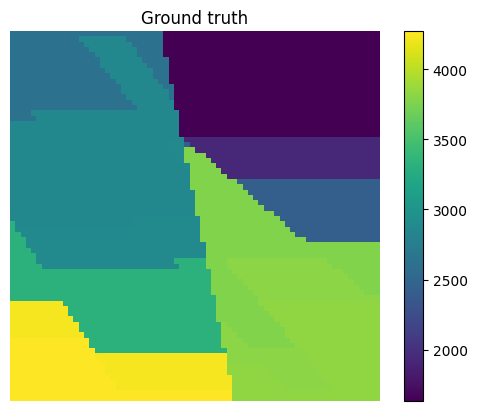

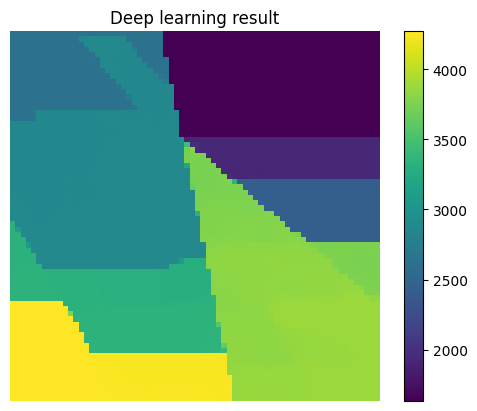

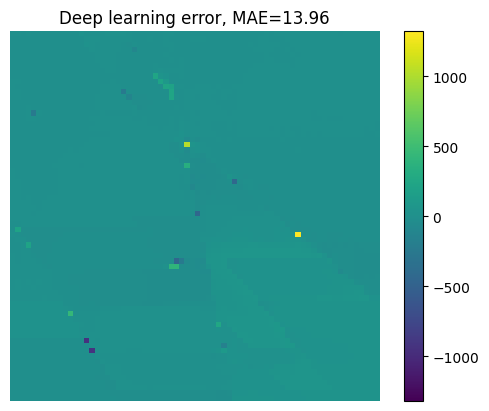

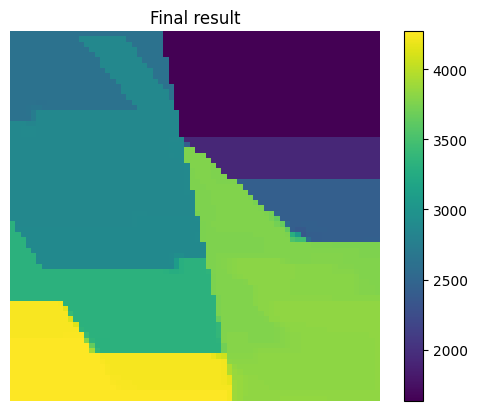

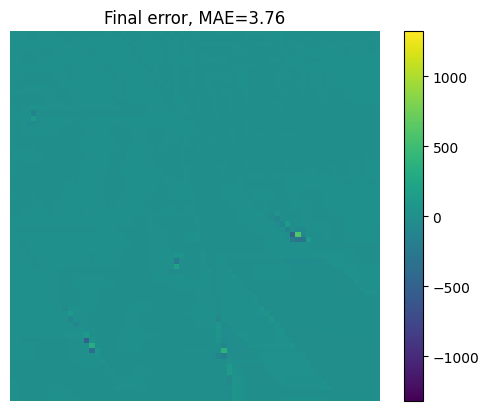

In [13]:
c1=[np.min(ground_truth), np.max(ground_truth)]
max_err = np.max(np.abs(res_brendan-ground_truth))
c2=[-max_err, max_err]
plt.figure()
plt.imshow(ground_truth)
plt.axis(False)
plt.clim(c1)
plt.colorbar()
plt.title('Ground truth')

plt.figure()
plt.imshow(res_brendan)
plt.axis(False)
plt.clim(c1)
plt.colorbar()
plt.title('Deep learning result')
plt.figure()
plt.imshow(res_brendan-ground_truth)
plt.axis(False)
plt.clim(c2)
plt.colorbar()
plt.title(f'Deep learning error, MAE={np.mean(np.abs(res_brendan-ground_truth)):.2f}')

plt.figure()
plt.imshow(res_full)
plt.axis(False)
plt.clim(c1)
plt.colorbar()
plt.title('Final result')
plt.figure()
plt.imshow(res_full-ground_truth)
plt.axis(False)
plt.clim(c2)
plt.colorbar()
plt.title(f'Final error, MAE={np.mean(np.abs(res_full-ground_truth)):.2f}')

In [14]:
65000/12

5416.666666666667

In [16]:
5416*0.125

677.0